In [ ]:
#import sys
#!{sys.executable} -m pip install tifffile imageio imageio[ffmpeg] napari[all]


## Data Analysis

In [ ]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np

file_name = "data/B Image 2.lsm"
with tiff.TiffFile(file_name) as tif:
    img = tif.asarray()

print("Shape:", img.shape)
print("Dtype:", img.dtype)

Shape: (73, 4, 388, 388)
Dtype: uint16


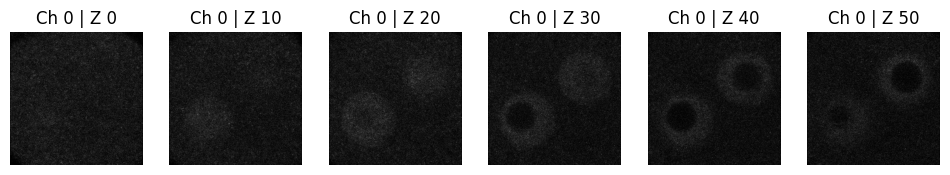

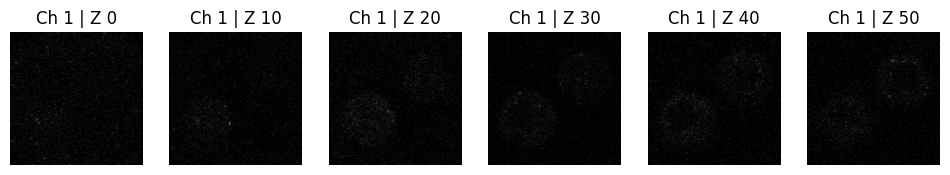

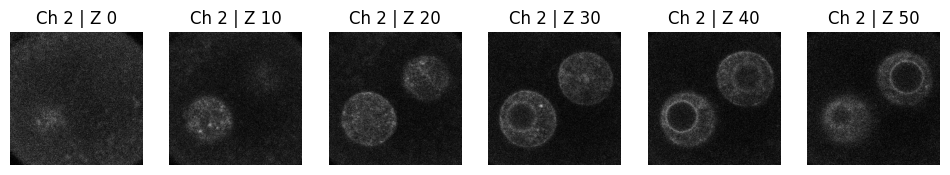

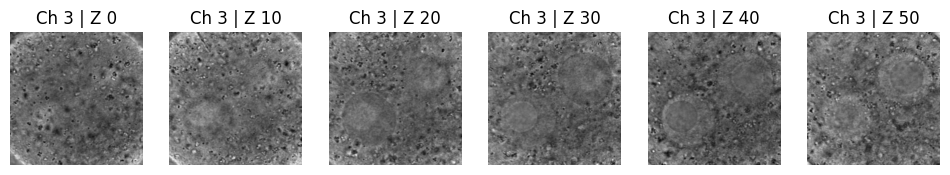

In [28]:
slices = [0, 10, 20, 30, 40, 50]

for c in range(4):
    plt.figure(figsize=(12,3))
    for i, z in enumerate(slices):
        plt.subplot(1, len(slices), i+1)
        plt.imshow(img[z, c], cmap='gray')
        plt.title(f"Ch {c} | Z {z}")
        plt.axis('off')
    plt.show()


Channel 0 = background / weak signal (not needed)

Channel 1 = spot channel (H2AX)
Faint small bright dots in the center region.

Channel 2 = ROI channel (nucleus + cell boundary)
You can clearly see the two circular structures here.

Channel 3 = brightfield / structural view (not needed)

## Channel extraction

In [ ]:
# extract relevant chanels

roi_stack = img[:, 2]
spot_stack = img[:, 1]
print("ROI min/max:", roi_stack.min(), roi_stack.max())
print("SPOT min/max:", spot_stack.min(), spot_stack.max())

ROI min/max: 0 50977
SPOT min/max: 0 50669


## 3D ROI Segmentation

In [ ]:
from scipy import ndimage as ndi
from scipy.ndimage import median_filter

from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.segmentation import watershed
from skimage.measure import label
from skimage.feature import peak_local_max


def segment_cells(roi_stack, debug=True):

    proj = np.mean(roi_stack.astype(np.float32), axis=0)
    smooth = gaussian(proj, sigma=2)


    # -----------------------------
    # smooth, remove background, normalise
    # -----------------------------
    smooth = gaussian(proj, sigma=1.5)
    bg = median_filter(smooth, size=101)
    flat = smooth - bg
    flat[flat < 0] = 0
    flat = (flat - flat.min()) / (flat.max() - flat.min() + 1e-8)


    # -----------------------------
    # Otsu threshold
    # -----------------------------
    t = threshold_otsu(flat)
    mask = flat > t*0.5


    # -----------------------------
    # Fill nucleus holes, remove noise, split touching cells
    # -----------------------------
    mask = ndi.binary_fill_holes(mask)
    mask = remove_small_objects(mask, 2000)
    distance = ndi.distance_transform_edt(mask)
    coords = peak_local_max(
        distance,
        min_distance=40,
        labels=mask
    )

    markers = np.zeros_like(mask, dtype=int)
    for i, (y, x) in enumerate(coords, start=1):
        markers[y, x] = i

    markers = ndi.label(markers)[0]
    labels = watershed(-distance, markers, mask=mask)

    # keep largest 2 objects
    lab = label(labels)
    sizes = ndi.sum(mask, lab, range(1, lab.max()+1))
    order = np.argsort(sizes)[::-1]
    final = np.zeros_like(labels)

    for i, idx in enumerate(order[:2]):
        final[lab == idx+1] = i+1


    # -----------------------------
    # Debug visualization
    # -----------------------------
    if debug:

        fig, ax = plt.subplots(2,4, figsize=(16,8))

        ax[0,0].imshow(proj, cmap="gray")
        ax[0,0].set_title("Projection")

        ax[0,1].imshow(flat, cmap="gray")
        ax[0,1].set_title("Background removed")

        ax[0,2].imshow(mask, cmap="gray")
        ax[0,2].set_title("Binary mask")

        ax[0,3].imshow(distance, cmap="magma")
        ax[0,3].set_title("Distance transform")

        ax[1,0].imshow(markers)
        ax[1,0].set_title("Markers")

        ax[1,1].imshow(labels)
        ax[1,1].set_title("Watershed")

        ax[1,2].imshow(final)
        ax[1,2].set_title("Final cells")

        ax[1,3].imshow(proj, cmap="gray")
        ax[1,3].contour(final>0, colors="red")
        ax[1,3].set_title("Overlay")

        for a in ax.ravel():
            a.axis("off")

        plt.tight_layout()
        plt.show()

    # expand to 3D
    mask3d = np.repeat((final>0)[None,:,:], roi_stack.shape[0], axis=0)
    labels3d = np.repeat(final[None,:,:], roi_stack.shape[0], axis=0)

    return {
        "projection": proj,
        "flat": flat,
        "mask": mask,
        "labels2d": final,
        "roi_mask_3d": mask3d,
        "roi_labels_3d": labels3d
    }

C:\Users\Manush\AppData\Local\Temp\ipykernel_14128\2130149012.py:64: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, 2000)


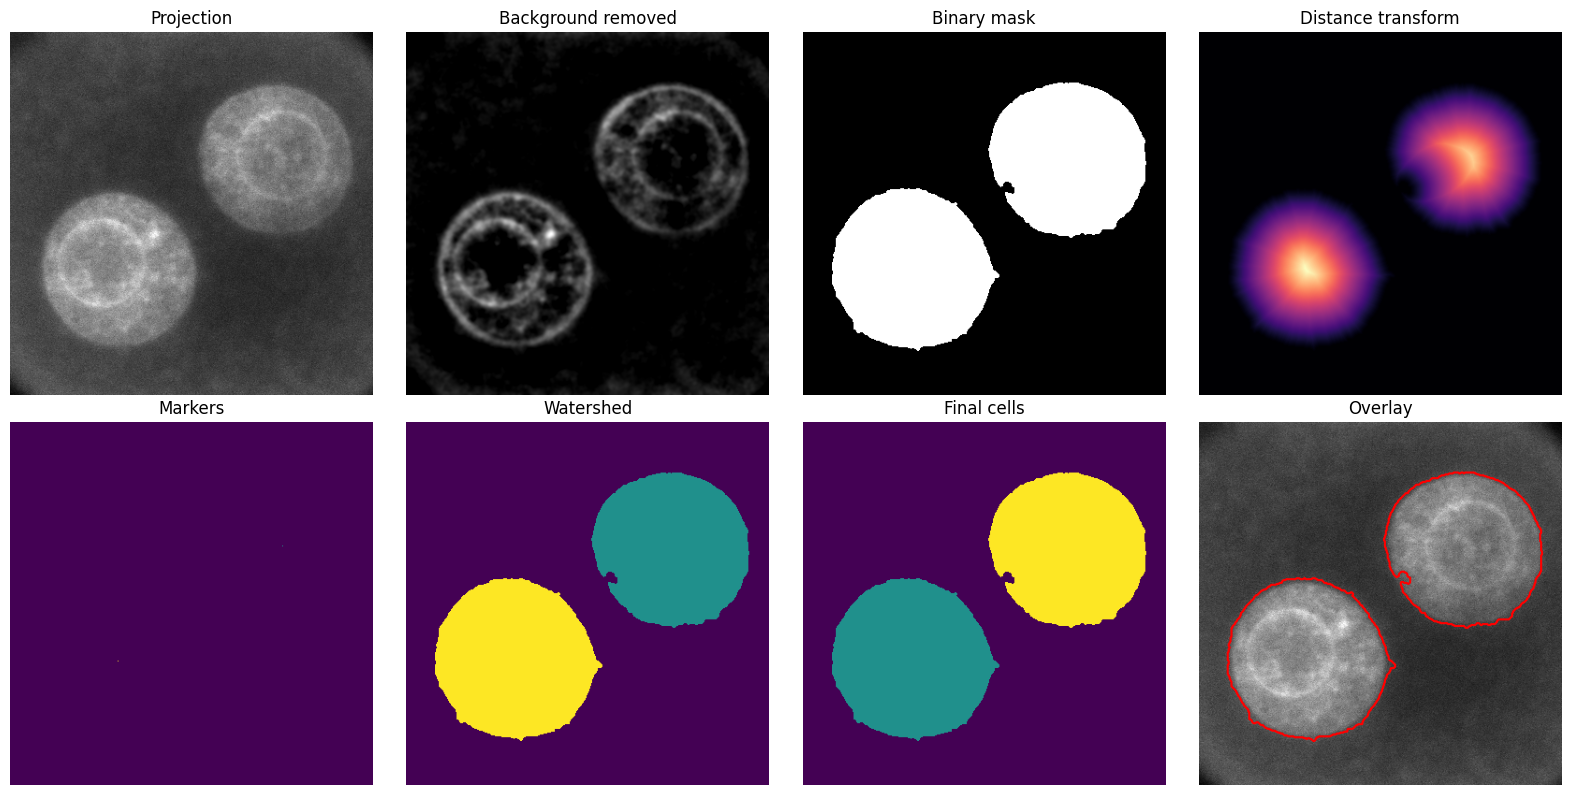

In [50]:
seg = segment_cells(roi_stack)

labels2d = seg["labels2d"]
roi_mask_3d = seg["roi_mask_3d"]
roi_labels_3d = seg["roi_labels_3d"]

## Spot Detection

In [ ]:
from scipy.spatial import cKDTree
from skimage.filters import gaussian
from skimage.feature import blob_log


# ---------------------------------------------------
# 1) Enhance spots, restrict to nucleus
# ---------------------------------------------------
spot_smooth = gaussian(spot_stack.astype(np.float32), sigma=(1, 1, 1))
roi_mask_3d = roi_mask_3d.astype(bool)

# zero out everything outside nuclei
spot_enh_masked = spot_smooth.copy()
spot_enh_masked[~roi_mask_3d] = 0

# threshold estimated only from nucleus pixels
vals = spot_enh_masked[roi_mask_3d]
threshold = np.percentile(vals, 99.5)
print("Adaptive threshold:", threshold)



# ---------------------------------------------------
# 3) 3D blob detection only inside nuclei
# ---------------------------------------------------
blobs = blob_log(
    spot_enh_masked,
    min_sigma=1.8,
    max_sigma=4,
    num_sigma=8,
    threshold=threshold
)

print("Total blobs detected (raw):", len(blobs))
blobs_in_roi = []

for blob in blobs:
    z, y, x, r = blob
    zi = int(round(z))
    yi = int(round(y))
    xi = int(round(x))

    if (
        0 <= zi < roi_mask_3d.shape[0]
        and 0 <= yi < roi_mask_3d.shape[1]
        and 0 <= xi < roi_mask_3d.shape[2]
        and roi_mask_3d[zi, yi, xi]
    ):
        blobs_in_roi.append(blob)

blobs_in_roi = np.array(blobs_in_roi) if len(blobs_in_roi) > 0 else np.empty((0, 4))
print("Blobs inside ROI:", len(blobs_in_roi))



# ---------------------------------------------------
# 4) 3D non-maximum suppression / merge duplicates
# ---------------------------------------------------
if len(blobs_in_roi) > 0:

    coords = blobs_in_roi[:, :3]  # (z, y, x)
    tree = cKDTree(coords)

    # merge centers within 3 voxels
    pairs = tree.query_pairs(r=3)  

    to_remove = set()
    for i, j in pairs:
        to_remove.add(j)

    keep_indices = [i for i in range(len(blobs_in_roi)) if i not in to_remove]
    blobs_filtered = blobs_in_roi[keep_indices]

else:
    blobs_filtered = np.empty((0, 4))

print("Blobs after merging:", len(blobs_filtered))



# ---------------------------------------------------
# 5) Assign each blob to nucleus 1 or nucleus 2
# ---------------------------------------------------
nucleus1_blobs = []
nucleus2_blobs = []

for blob in blobs_filtered:
    z, y, x, r = blob
    zi = int(round(z))
    yi = int(round(y))
    xi = int(round(x))

    label = roi_labels_3d[zi, yi, xi]

    if label == 1:
        nucleus1_blobs.append(blob)
    elif label == 2:
        nucleus2_blobs.append(blob)

nucleus1_blobs = np.array(nucleus1_blobs) if len(nucleus1_blobs) > 0 else np.empty((0, 4))
nucleus2_blobs = np.array(nucleus2_blobs) if len(nucleus2_blobs) > 0 else np.empty((0, 4))

print("Nucleus 1 spots:", len(nucleus1_blobs))
print("Nucleus 2 spots:", len(nucleus2_blobs))

Adaptive threshold: 4157.7373
Total blobs detected (raw): 17
Blobs inside ROI: 17
Blobs after merging: 17
Nucleus 1 spots: 6
Nucleus 2 spots: 11


## Visualize Spots, Save CSV

In [ ]:
import imageio

frames = []

for z_slice in range(spot_stack.shape[0]):

    fig, ax = plt.subplots(figsize=(4,4))
    ax.imshow(spot_stack[z_slice], cmap="gray")

    for z, y, x, r in blobs_filtered:
        if int(round(z)) == z_slice:
            ax.scatter(x, y, s=40, edgecolor='red', facecolor='none', linewidth=1.2)

    ax.set_title(f"Z = {z_slice}")
    ax.axis("off")

    fig.canvas.draw()
    frame = np.array(fig.canvas.renderer.buffer_rgba())
    frames.append(frame)

    plt.close(fig)

imageio.mimsave("detections.mp4", frames, fps=5)
print("Video saved as detections.mp4")

from IPython.display import Video
Video("detections.mp4")

Video saved as detections.mp4


In [ ]:
import os
import pandas as pd

base_name = os.path.splitext(os.path.basename(file_name))[0]
rows = [
    {
        "filename_cellnumber": f"{base_name}_cell1",
        "spot_count": len(nucleus1_blobs)
    },
    {
        "filename_cellnumber": f"{base_name}_cell2",
        "spot_count": len(nucleus2_blobs)
    }
]

df = pd.DataFrame(rows)
csv_path = f"{base_name}_spot_counts.csv"
df.to_csv(csv_path, index=False)

print("Saved CSV:", csv_path)

Saved CSV: B Image 2_spot_counts.csv
